# Visualize Model Training Results

On merged classes.

This notebook summarizes the relevant metrics on the test set. Note that if merge is set to True in the first cell, the classes considered are:

- Bosmina
- Calanoid
- Chydoridae
- Chironomid
- Cyclopoid
- Daphnia
- Harpacticoid
- Other: Bubbles, Floc 1 & 2, LargeZ-1, Nauploo, Sididae, TooSmall

The model trains and predicts on each class individually. The "Other" category is created by merging the 7 classes into 1 class. Then, for an observation in any of those 7 classes, a prediction is considered to be a True Positive as long as it is one of those 7 classes. If however merge is set to False, then the original 14 classes are considered.

#### SELECT PARAMETERS


In [6]:
# Corresponds to the desired model for displaying results

run_name = '20250627_150251_densenet121'
run_name = '20250714_154523_densenet121'

run_name = '20250715_101547_densenet121'
run_name = '20250717_184244_densenet121'

In [7]:
# Whether to consider the original 14 classes or merge them

merge = True

### Notebook & Data Set-Up

In [8]:
# Imports
import os
from collections import defaultdict

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from sklearn.metrics import *
from sklearn.preprocessing import label_binarize

In [9]:
# Paths
data_directory = '/data/zooplankton_data'
root_directory = os.path.abspath('')

weights_path = os.path.join(root_directory, 'weights', run_name + '.pth')
predictions_path = os.path.join(root_directory, 'predictions', run_name + '.pth')
metadata_path = os.path.join(root_directory, 'environment', run_name + '.pth')

In [13]:
# Load predictions
predictions = torch.load(predictions_path, map_location = torch.device('cpu'))
y_true = predictions[0].numpy()
y_pred = predictions[2].numpy()
y_prob = predictions[1].numpy()

# Load environment/metadata variables
metadata = torch.load(metadata_path, weights_only = False)
model_id, model_name = metadata['model_id'], metadata['model_name']
classes, class_map = metadata['classes'], metadata['class_map']
train_metrics = metadata['train_metrics']
hyperparameters = metadata['hyperparameters']
# image_transforms = metadata['image_transforms']

class_map_rev = {v: k for k, v in class_map.items()}

In [11]:
# Define function to merge classes

def reorder_and_merge_classes(class_map, y_true, y_pred, y_prob, to_merge):

    class_map_rev = {v: k for k, v in class_map.items()} # Inverse class map

    # Create new class map with main classes + other
    to_keep = sorted([cls for cls in class_map if cls not in to_merge])
    new_class_map = {cls: idx for idx, cls in enumerate(to_keep)}

    other_index = len(to_keep)
    new_class_map['Other'] = other_index

    # Map old indices to new indices
    orig_max_index = max(class_map.values())
    orig_to_new_map = np.zeros(orig_max_index + 1, dtype = int)

    for orig_idx, cls in class_map_rev.items():
        if cls in to_merge:
            orig_to_new_map[orig_idx] = other_index
        else:
            orig_to_new_map[orig_idx] = new_class_map[cls]

    # Map labels
    new_y_true = orig_to_new_map[y_true]
    new_y_pred = orig_to_new_map[y_pred]

    # Map prediction probabilities
    n_samples = y_prob.shape[0]
    new_n_classes = len(new_class_map)
    new_y_prob = np.zeros((n_samples, new_n_classes))
    
    for orig_idx, cls in class_map_rev.items():
        new_idx = new_class_map['Other'] if cls in to_merge else new_class_map[cls]
        new_y_prob[:, new_idx] += y_prob[:, orig_idx]

    # Need to normalize due to floating-point precision
    y_prob_sums = new_y_prob.sum(axis = 1, keepdims = True)
    new_y_prob = new_y_prob / y_prob_sums

    return new_class_map, new_y_true, new_y_pred, new_y_prob

In [14]:
# Merge classes
to_merge = ['Bubbles', 'Floc_1', 'Floc_2', 'LargeZ-1', 'Nauplii', 'Sididae', 'TooSmall']

if merge:
    class_map, y_true, y_pred, y_prob = reorder_and_merge_classes(class_map, y_true, y_pred, y_prob, to_merge)
    
class_map_rev = {v: k for k, v in class_map.items()}
classes = list(class_map.keys())

In [15]:
print(f'Selected Model: {model_name} (ID: {model_id})')
print('\nClasses:\n ' + '\n '.join(f'{cln}: {clid}' for cln, clid in class_map.items()))
print('\nTraining Parameters:\n ' + '\n '.join(f'{p}: {pv}' for p, pv in hyperparameters.items()))

# print('\nSum of Weights: ', hyperparameters['loss_fn']['weights'].sum())

Selected Model: densenet121 (ID: 20250717_184244)

Classes:
 Bosmina_1: 0
 Calanoid_1: 1
 Chironomid: 2
 Chydoridae: 3
 Cyclopoid_1: 4
 Daphnia: 5
 Herpacticoida: 6
 Other: 7

Training Parameters:
 loss_fn: {'type': 'CrossEntropyLoss', 'weights': tensor([0.0713, 0.0713, 0.0713, 0.0713, 0.0718, 0.0713, 0.0715, 0.0713, 0.0724,
        0.0713, 0.0713, 0.0714, 0.0715, 0.0713])}
 optimizer: Adam
 lr: 0.0005
 epochs: 80
 scheduler: {'type': 'CosineAnnealingLR', 'T_max': 50}
 early_stopping: {'patience': 15, 'delta': 0.005}
 batch_size: 64


### Train Performance

Model trained for 57 epochs.


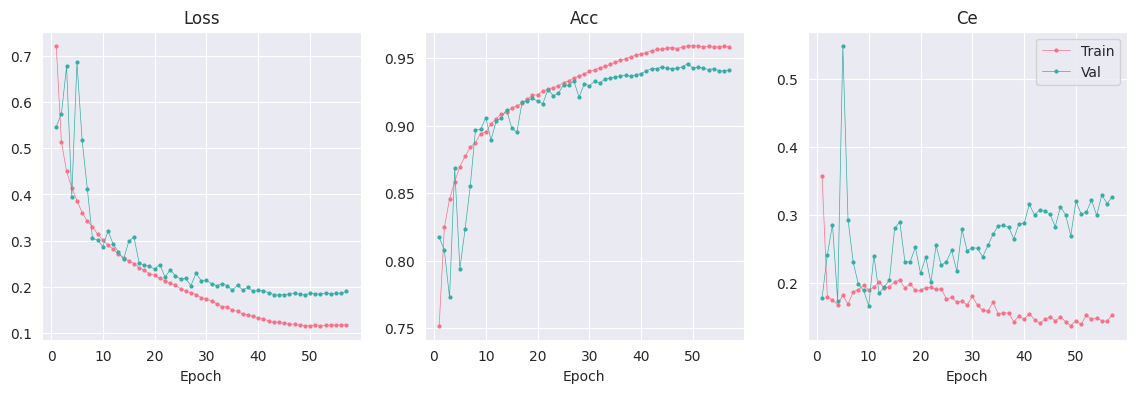

In [17]:
actual_epochs = len(train_metrics['train_acc'])
print(f'Model trained for {actual_epochs} epochs.')

# Plot
sns.set_style('darkgrid')
fig, axes = plt.subplots(1, 3, figsize = (14, 4), sharex = True)
palette = sns.color_palette('husl', n_colors = 2)

metrics = ['loss', 'acc', 'ce']
epochs_enum = list(range(1, actual_epochs+1))

for i, metric in enumerate(metrics):
    train_values = train_metrics[f'train_{metric}']
    val_values = train_metrics[f'test_{metric}']

    if metric == 'acc':
        val_values = [x / 100 for x in val_values]

    axes[i].plot(epochs_enum, train_values, label = f'Train', marker = 'o', markersize = 2, lw = 0.5, color = palette[0])
    axes[i].plot(epochs_enum, val_values, label = f'Val', marker = 'o', markersize = 2, lw = 0.5, color = palette[1])
    
    axes[i].set_title(metric.capitalize())
    axes[i].set_xlabel('Epoch')
    
plt.legend()
plt.show()


### Test Performance

#### Overall Metrics

In [18]:
# Compute overall metrics
acc = accuracy_score(y_true, y_pred)

prec_avg = precision_score(y_true, y_pred, average = 'macro')
prec_w_avg = precision_score(y_true, y_pred, average = 'weighted')

recall_avg = recall_score(y_true, y_pred, average = 'macro')
recall_w_avg = recall_score(y_true, y_pred, average = 'weighted')

f1_avg = f1_score(y_true, y_pred, average = 'macro')
f1_w_avg = f1_score(y_true, y_pred, average = 'weighted')

ce = log_loss(y_true, y_prob)

In [19]:
# Print
print(f'Accuracy: {acc:.4f}\n')
print(f'Average Precision: {prec_avg:.4f}\nWeighted Precision: {prec_w_avg:.4f}\n')
print(f'Average Recall: {recall_avg:.4f}\nWeighted Recall: {recall_w_avg:.4f}\n')
print(f'Average F1: {f1_avg:.4f}\nWeighted F1: {f1_w_avg:.4f}\n')
print(f'Cross Entropy: {ce:.4f}')

Accuracy: 0.9638

Average Precision: 0.8716
Weighted Precision: 0.9636

Average Recall: 0.8416
Weighted Recall: 0.9638

Average F1: 0.8491
Weighted F1: 0.9635

Cross Entropy: 0.1204


#### Confusion Matrices

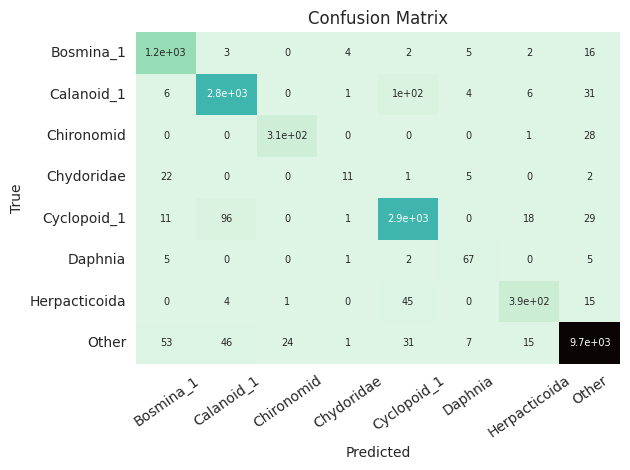

In [21]:
# Get confusion matrix data
cm = confusion_matrix(y_true, y_pred)
annot_kws = {'size': 7}

# Plot
sns.heatmap(cm, annot = True, annot_kws = annot_kws, cmap = 'mako_r', xticklabels = classes, yticklabels = classes, cbar = False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation = 35)

plt.tight_layout()
plt.show()

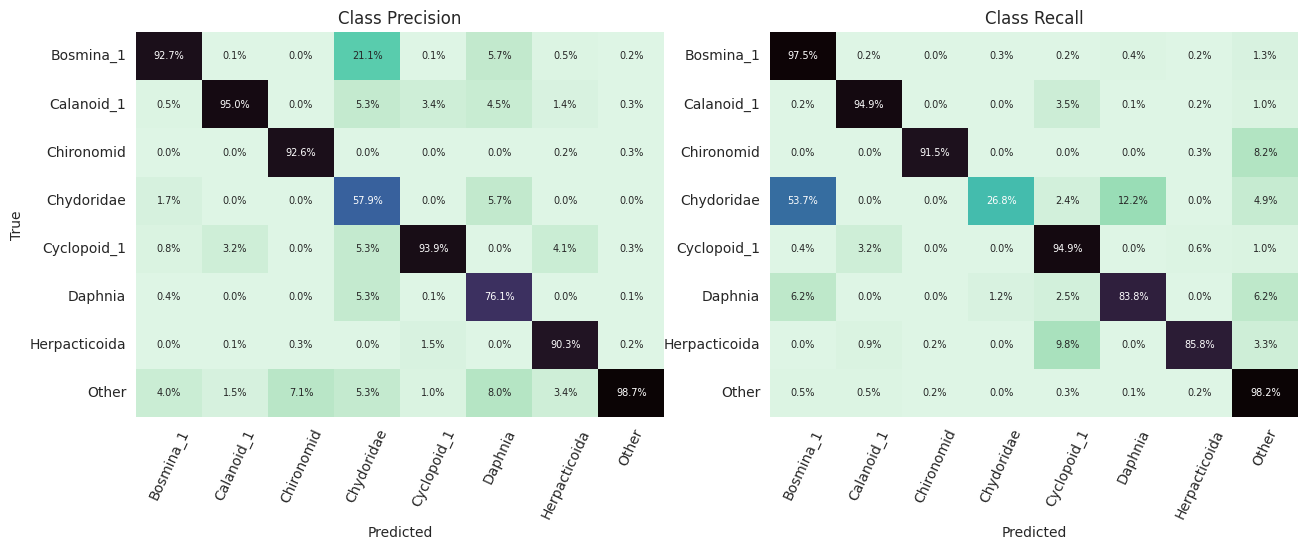

In [22]:
# Get confusion matrix data
cm_col_percent = cm / cm.sum(axis = 0, keepdims = True)
annot_col = np.array([[f"{val:.01%}" for val in row] for row in cm_col_percent])

cm_row_percent = cm / cm.sum(axis = 1, keepdims = True)
annot_row = np.array([[f"{val:.01%}" for val in col] for col in cm_row_percent])

# Plot
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(cm_col_percent, annot = annot_col, annot_kws = annot_kws, fmt = '', cmap = 'mako_r', xticklabels = classes, yticklabels = classes, cbar = False, ax = axs[0])
axs[0].set_xlabel('Predicted')
axs[0].set_ylabel('True')
axs[0].set_title('Class Precision')
axs[0].tick_params(axis = 'x', rotation = 65)

sns.heatmap(cm_row_percent, annot = annot_row, annot_kws = annot_kws, fmt = '', cmap = 'mako_r', xticklabels = classes, yticklabels = classes, cbar = False, ax = axs[1])
axs[1].set_xlabel('Predicted')
# axs[1].set_ylabel('True')
axs[1].set_title('Class Recall')
axs[1].tick_params(axis = 'x', rotation = 65)

plt.show()

#### Per Class Metrics

In [23]:
# Compute per class metrics
prec_per_class = precision_score(y_true, y_pred, average = None)
recall_per_class = recall_score(y_true, y_pred, average = None)

# Cross-entropy
y_true_tensor = torch.from_numpy(y_true).long()
y_logit_tensor = torch.from_numpy(y_prob).float().log()

ce_all = F.cross_entropy(y_logit_tensor, y_true_tensor, reduction = 'none')
class_ces = defaultdict(list)

for ce, y in zip(ce_all, y_true_tensor):
    class_ces[int(y)].append(ce.item())

ce_per_class = np.full(len(classes), np.nan)
for clid in range(len(classes)):
    if class_ces[clid]:
        ce_per_class[clid] = np.mean(class_ces[clid])

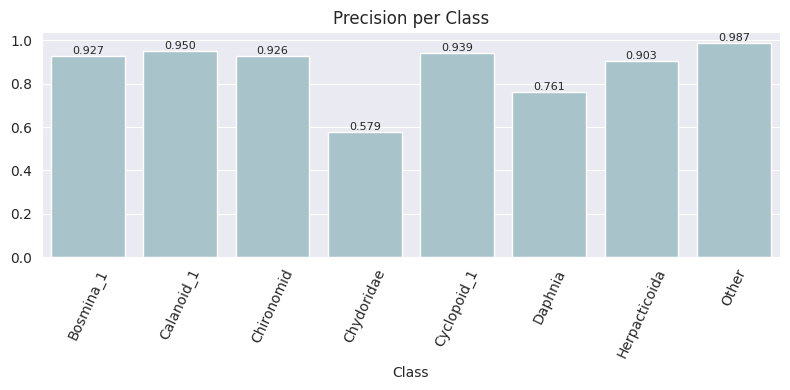

In [24]:
# Plot precision per class
sns.set_style('darkgrid')
plt.figure(figsize=(8,4))

ax = sns.barplot(x = classes, y = prec_per_class, color = '#a3c6cf')
plt.title('Precision per Class')
plt.xlabel('Class')
ax.bar_label(ax.containers[0], fmt = '%.3f', fontsize = 8)
ax.tick_params(axis = 'x', rotation = 65)

plt.tight_layout()
plt.show()

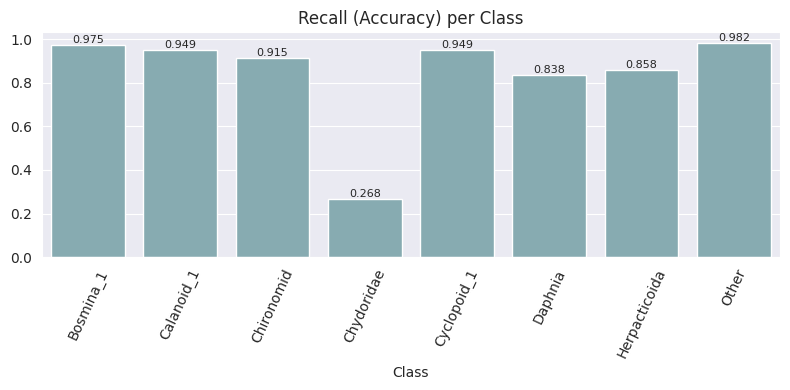

In [25]:
# Plot recall (aka accuracy) per class
sns.set_style('darkgrid')
plt.figure(figsize=(8,4))

ax = sns.barplot(x = classes, y = recall_per_class, color = '#80b0b8')
plt.title('Recall (Accuracy) per Class')
plt.xlabel('Class')
ax.bar_label(ax.containers[0], fmt = '%.3f', fontsize = 8)
ax.tick_params(axis = 'x', rotation = 65)

plt.tight_layout()
plt.show()

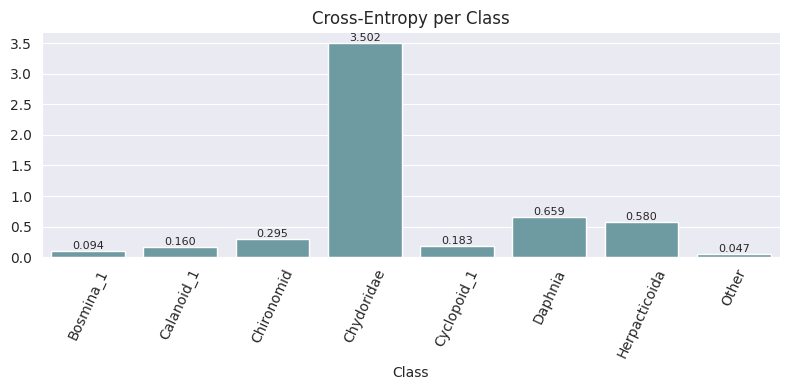

In [26]:
# Plot cross-entropy per class
sns.set_style('darkgrid')
plt.figure(figsize=(8,4))

ax = sns.barplot(x = classes, y = ce_per_class, color = '#66a2a9')
plt.title('Cross-Entropy per Class')
plt.xlabel('Class')
ax.bar_label(ax.containers[0], fmt = '%.3f', fontsize = 8)
ax.tick_params(axis = 'x', rotation = 65)

plt.tight_layout()
plt.show()